# **클래스 선언 방식**


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')
    plt.plot(epochs, val_acc_list, label='val_acc', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

* 다운로드

In [8]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.1MB/s]


* 데이터 축소
    * 다양한 실험을 하기 위해 데이터 사이즈를 줄여서 진행합니다.
    * 아래 코드는 흐름만 살펴보세요. 하나하나 다 이해할 필요는 없습니다.

In [9]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링, 층화추출
x_train, _, y_train, _ = train_test_split(train_data, train_labels, test_size = 40000, random_state = 10, stratify = train_labels)
x_val, x_test, y_val, y_test = train_test_split(test_data, test_labels, test_size = 5000, random_state = 10, stratify = test_labels)

# 3 --> 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

* y(target)의 클래스

In [10]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* train은 데이터로더로 생성

In [11]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size)

## **3.모델링**

### (1) 기존방식

* 모델 선언

In [12]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(4 * 14 * 14, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


* 학습

Epoch 1, train loss : 0.8644, val loss : 0.5617, val acc : 0.7976
Epoch 2, train loss : 0.4848, val loss : 0.4795, val acc : 0.8242
Epoch 3, train loss : 0.4285, val loss : 0.4448, val acc : 0.8398
Epoch 4, train loss : 0.4000, val loss : 0.4252, val acc : 0.8468
Epoch 5, train loss : 0.3813, val loss : 0.4123, val acc : 0.8520
Epoch 6, train loss : 0.3674, val loss : 0.4033, val acc : 0.8566
Epoch 7, train loss : 0.3562, val loss : 0.3965, val acc : 0.8596
Epoch 8, train loss : 0.3469, val loss : 0.3914, val acc : 0.8624
Epoch 9, train loss : 0.3387, val loss : 0.3873, val acc : 0.8652
Epoch 10, train loss : 0.3316, val loss : 0.3842, val acc : 0.8664


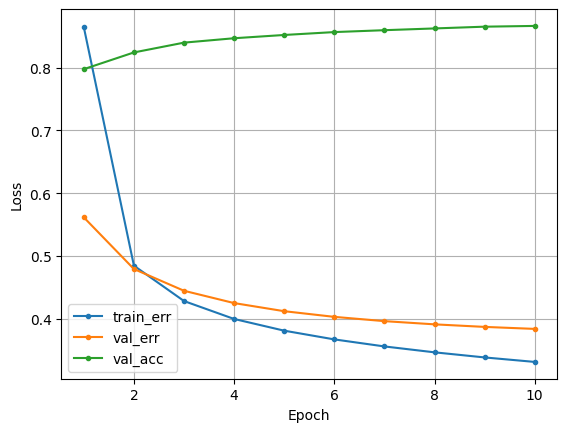

In [13]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델 평가

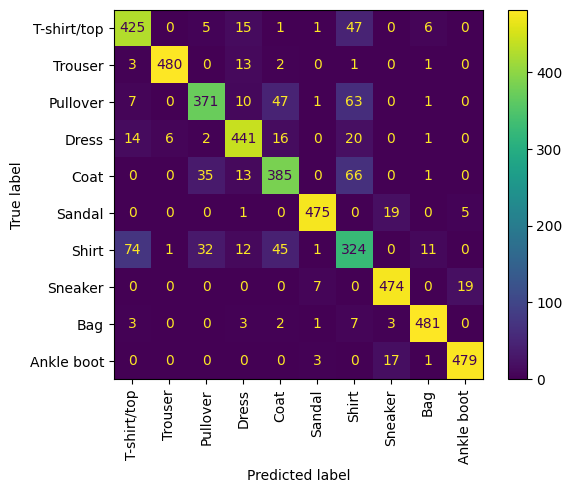

Accuracy : 0.867
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.85      0.83       500
     Trouser       0.99      0.96      0.97       500
    Pullover       0.83      0.74      0.79       500
       Dress       0.87      0.88      0.88       500
        Coat       0.77      0.77      0.77       500
      Sandal       0.97      0.95      0.96       500
       Shirt       0.61      0.65      0.63       500
     Sneaker       0.92      0.95      0.94       500
         Bag       0.96      0.96      0.96       500
  Ankle boot       0.95      0.96      0.96       500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [14]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (2) 클래스 방식

* 클래스 생성

In [15]:
class CustomCNN(nn.Module):                  # nn.Module : PyTorch의 기본 클래스, 이 클래스를 상속받음.
    def __init__(self, n_class):             # 클래스가 인스턴스화될 때 호출되는 초기화 메서드. 모델의 구조와 파라미터를 정의
        super(CustomCNN, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(4*14*14, n_class)

    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x

* 모델 선언

In [16]:
n_class = 10
model = CustomCNN(n_class).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
           Flatten-4                  [-1, 784]               0
            Linear-5                   [-1, 10]           7,850
Total params: 7,890
Trainable params: 7,890
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total Size (MB): 0.09
----------------------------------------------------------------


* 학습

Epoch 1, train loss : 0.9218, val loss : 0.5809, val acc : 0.7864
Epoch 2, train loss : 0.4976, val loss : 0.5005, val acc : 0.8172
Epoch 3, train loss : 0.4449, val loss : 0.4667, val acc : 0.8310
Epoch 4, train loss : 0.4190, val loss : 0.4468, val acc : 0.8394
Epoch 5, train loss : 0.4023, val loss : 0.4334, val acc : 0.8448
Epoch 6, train loss : 0.3899, val loss : 0.4237, val acc : 0.8500
Epoch 7, train loss : 0.3799, val loss : 0.4160, val acc : 0.8540
Epoch 8, train loss : 0.3715, val loss : 0.4098, val acc : 0.8564
Epoch 9, train loss : 0.3641, val loss : 0.4049, val acc : 0.8586
Epoch 10, train loss : 0.3576, val loss : 0.4004, val acc : 0.8616


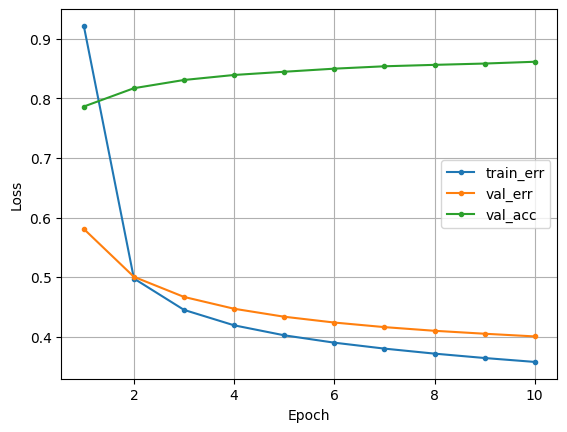

In [17]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델 평가

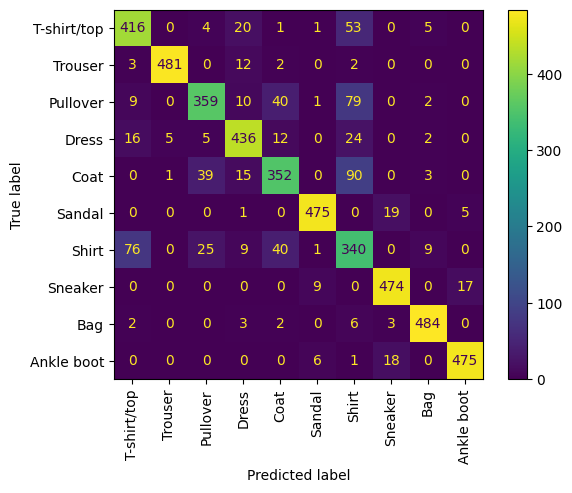

Accuracy : 0.8584
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.83      0.81       500
     Trouser       0.99      0.96      0.97       500
    Pullover       0.83      0.72      0.77       500
       Dress       0.86      0.87      0.87       500
        Coat       0.78      0.70      0.74       500
      Sandal       0.96      0.95      0.96       500
       Shirt       0.57      0.68      0.62       500
     Sneaker       0.92      0.95      0.93       500
         Bag       0.96      0.97      0.96       500
  Ankle boot       0.96      0.95      0.95       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



In [18]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

## **4.실습**



### (1) 실습1

#### 1) 기존 모델 설계

In [19]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)
# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                   [-1, 10]           3,930
Total params: 4,266
Trainable params: 4,266
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.02
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


#### 2) 클래스 방식
* 클래스 생성

In [20]:
class CustomCNN(nn.Module):
    def __init__(self, n_class):
        super(CustomCNN, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride = 1 ,padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, stride = 1, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(8*14*14, n_class)
    def forward(self, x):
        # 모델 설계
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.fc1(x)
        return x

* 모델 선언

In [21]:
n_class = 10
model2 = CustomCNN(n_class).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

* 학습

Epoch 1, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 2, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 3, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 4, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 5, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 6, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 7, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 8, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 9, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996
Epoch 10, train loss : 2.3126, val loss : 2.3132, val acc : 0.0996


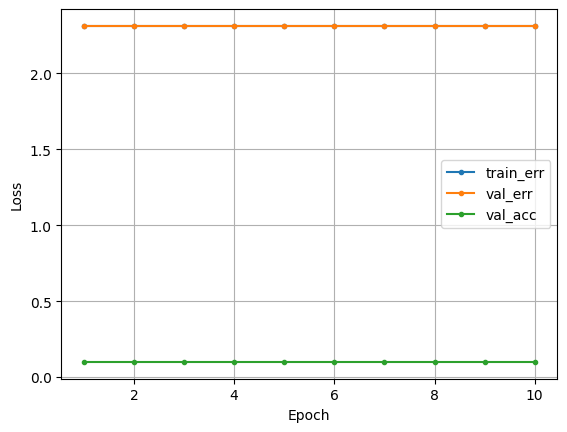

In [22]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델 평가

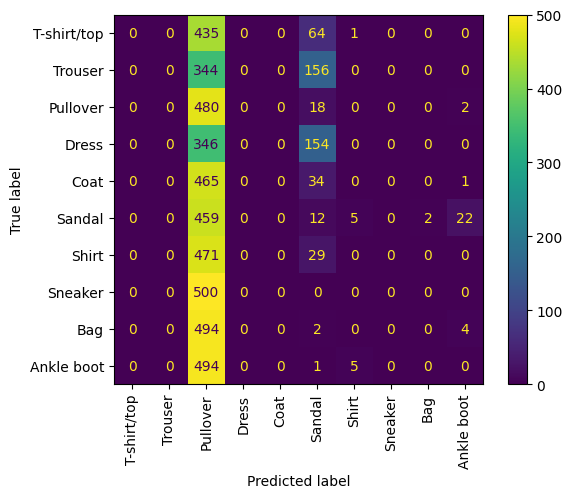

Accuracy : 0.0984
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.00      0.00      0.00       500
     Trouser       0.00      0.00      0.00       500
    Pullover       0.11      0.96      0.19       500
       Dress       0.00      0.00      0.00       500
        Coat       0.00      0.00      0.00       500
      Sandal       0.03      0.02      0.02       500
       Shirt       0.00      0.00      0.00       500
     Sneaker       0.00      0.00      0.00       500
         Bag       0.00      0.00      0.00       500
  Ankle boot       0.00      0.00      0.00       500

    accuracy                           0.10      5000
   macro avg       0.01      0.10      0.02      5000
weighted avg       0.01      0.10      0.02      5000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# 예측
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))

### (1) 실습2

#### 1) 기존 모델 설계

In [24]:
n_class = 10

# 모델 구조 설계
model = nn.Sequential(
    nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

# 모델 요약
summary(model, input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 28, 28]              40
              ReLU-2            [-1, 4, 28, 28]               0
         MaxPool2d-3            [-1, 4, 14, 14]               0
            Conv2d-4            [-1, 8, 14, 14]             296
              ReLU-5            [-1, 8, 14, 14]               0
         MaxPool2d-6              [-1, 8, 7, 7]               0
           Flatten-7                  [-1, 392]               0
            Linear-8                  [-1, 128]          50,304
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 51,930
Trainable params: 51,930
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.09
Params size (MB): 0.20
Estimated Tot

#### 2) 클래스 방식
* 클래스 생성

In [38]:
class CustomCNN(nn.Module):
    def __init__(self, n_class):
        super(CustomCNN, self).__init__()
        # 필요한 레이어 정의(초기화)
        self.conv1d = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
        self.reluj = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2d = nn.Conv2d(4, 8, kernel_size=3, stride=1, padding=1)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(8*7*7, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, n_class)
    def forward(self, x):
        # 모델 설계
        x = self.conv1d(x)
        x = self.reluj(x)
        x = self.pool(x)

        x = self.conv2d(x)
        x = self.reluj(x)
        x = self.pool(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

* 모델 선언

In [39]:
n_class = 10
model3 = CustomCNN(n_class).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

* 학습

Epoch 1, train loss : 0.9802, val loss : 0.6525, val acc : 0.7380
Epoch 2, train loss : 0.5775, val loss : 0.5657, val acc : 0.7798
Epoch 3, train loss : 0.5079, val loss : 0.5096, val acc : 0.8078
Epoch 4, train loss : 0.4627, val loss : 0.4699, val acc : 0.8286
Epoch 5, train loss : 0.4292, val loss : 0.4456, val acc : 0.8392
Epoch 6, train loss : 0.4059, val loss : 0.4318, val acc : 0.8432
Epoch 7, train loss : 0.3885, val loss : 0.4205, val acc : 0.8488
Epoch 8, train loss : 0.3745, val loss : 0.4140, val acc : 0.8498
Epoch 9, train loss : 0.3624, val loss : 0.4074, val acc : 0.8524
Epoch 10, train loss : 0.3515, val loss : 0.4012, val acc : 0.8532


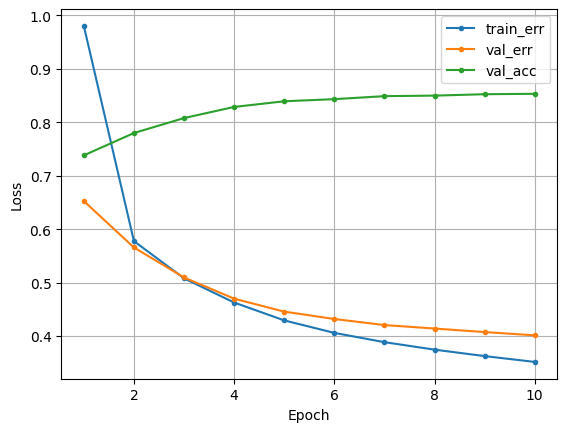

In [40]:
epochs = 10
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)

    # accuracy 측정
    pred = nn.functional.softmax(pred, dim=1)
    pred = np.argmax(pred.cpu().numpy(), axis = 1)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)     # train - CrossEntropy
    val_loss_list.append(val_loss)   # val - CrossEntropy
    val_acc_list.append(acc)         # val - Accuracy

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

* 모델 평가

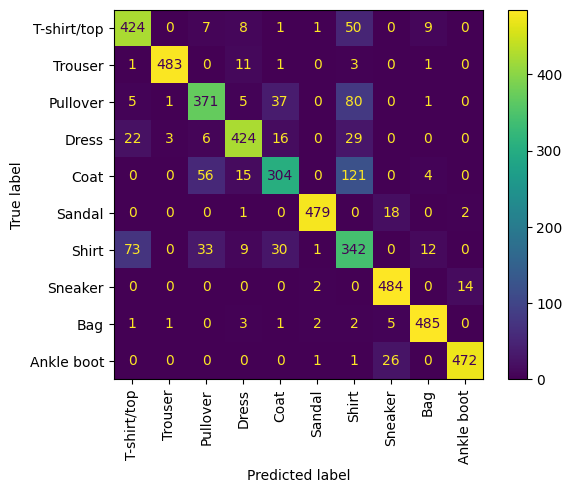

Accuracy : 0.8536
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.85      0.83       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.78      0.74      0.76       500
       Dress       0.89      0.85      0.87       500
        Coat       0.78      0.61      0.68       500
      Sandal       0.99      0.96      0.97       500
       Shirt       0.54      0.68      0.61       500
     Sneaker       0.91      0.97      0.94       500
         Bag       0.95      0.97      0.96       500
  Ankle boot       0.97      0.94      0.96       500

    accuracy                           0.85      5000
   macro avg       0.86      0.85      0.85      5000
weighted avg       0.86      0.85      0.85      5000



In [42]:
# 예측
_, pred = evaluate(x_test, y_test, model3, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

# classification report
print('='*80)
print(f'Accuracy : {accuracy_score(y_test.numpy(), pred)}')
print('-'*80)
print(classification_report(y_test.numpy(), pred, target_names=classes))